# <u>**Laboratório 1 - Captura de Imagem e Vídeo**</u>

**Integrantes**

- Gabriel Intackli Pinto - 11201921426

- Lucas Medeiros da Silva - 11202130277

- Samira Haddad - 11201812350

**Data de Realização dos Experimentos**

01/06/2026

**Data de Publicação do Relatório**

01/06/2026

## <u>Introdução</u>

Neste experimento será demonstrada a leitura, captura e modificação de imagens e vídeos utilizando uma webcam por meio da linguagem Python em ambiente Linux. A atividade será dividida em duas etapas: a primeira consiste na análise e explicação dos códigos apresentados em sala, aplicados a imagens e vídeos fornecidos pelo professor, já a segunda envolve a adaptação desses códigos para capturar e processar imagens e vídeos obtidos pelas webcams dos integrantes do grupo.

## <u>Procedimentos Experimentais</u>

## **PARTE 1 - Processamento Básico nas Imagens e Vídeos**

### (A) <u>Leitura de imagem em arquivo</u>

O programa “L__1_img.py” realiza a leitura e de
imagem gravado num arquivo e mostra a imagem numa janela do linux.

Além disso, o programa permite salvar a imagem em arquivo.

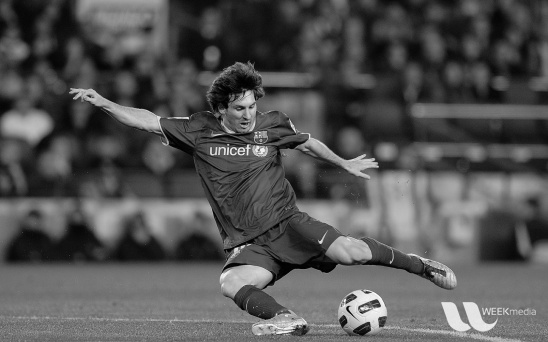

In [ ]:
# L__1_img.py
import numpy as np
import cv2 as cv

img = cv.imread('messi5.jpg',0)
cv.imshow('image', img)
k = cv.waitKey(0)
if k == 27:         # wait for ESC key to exit
    cv.destroyAllWindows()
elif k == ord('s'): # wait for 's' key to save and exit
    cv.imwrite('messigray.png',img)
    cv.destroyAllWindows()

<u>**Pergunta**</u>: por que a janela aberta não mostra a imagem colorida?

<u>**Resposta**</u>: Na linha 4 temos o comando cv.imread('messi5.jpg',0), ele é utilizado para carregar em memória uma determinada imagem, o primeiro parâmetro dessa função é o nome do arquivo, o segundo é a escala que desejamos ler o arquivo, o cv2.IMREAD_GRAYSCALE ou 0 carrega a imagem em preto e branco (grayscale)

### (B) <u>Leitura de vídeo em arquivo</u>

O programa “L__2_video.py” realiza a leitura de video
gravado num arquivo e exibe a sequencia das imagems numa janela do linux.

In [ ]:
import time
import numpy as np
import cv2 as cv

cap = cv.VideoCapture('big_buck_bunny.mp4')

while(cap.isOpened()):
    ret, frame = cap.read()

    if ret==True:

        cv.imshow('frame', frame)

        #wait next frame by 40ms - 25fps
        time.sleep(1/25.0)

        if cv.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        break

cap.release()
cv.destroyAllWindows()

<u>**Altere e Responda**</u>: Modifique o programa para que as imagens sejam exibidas mais rápidamente e depois para que sejam exibidas mais lentamente. Qual
explicação de alteração de velocidade de exibição, e apresente suas soluções
detalhadamente.


In [ ]:
import time
import numpy as np
import cv2 as cv

cap = cv.VideoCapture('big_buck_bunny.mp4')

while(cap.isOpened()):
    ret, frame = cap.read()

    if ret==True:

        cv.imshow('frame', frame)

        #wait next frame by 40ms - 25fps
        time.sleep(1/120.0) # Mais rápido

        #time.sleep(1/10.0) - Mais lento

        if cv.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        break

cap.release()
cv.destroyAllWindows()

<u>**Resposta**</u>:A percepção de movimento em um vídeo, nada mais é do que uma sequência de imagens mostradas a tela em uma velocidade tão grande que temos a ilusão de movimento conforme a sequência de imagens é exibida. Conforme vamos aumentando a velocidade de frames (imagens) temos também a impressão de que o movimento está ficando + ou - rápido (podemos notar esse efeito quando alteramos a velocidade de um vídeo no youtube de 1x para 2x, o que muda é simplesmente a frequência de apresentação desses frames e a velocidade do aúdio). Para deixar o vídeo mais ou menos rápido basta alterar essa "velocidade" de exibição dos frames. O que possibilita controlar a velocidade de exibição dos frames é justamente a linha 15 do arquivo L__2_video.py (time.sleep(1/25)), nela setamos a quantidade de frames que serão exibidos por segundo (fps), o original está setado em 25 fps (1/25 segundos para cada frame), para aumentar a velocidade para 120 fps podemos mudar essa linha para time.sleep(1/120.0) e para diminuir a velocidade para 10 fps podemos mudar essa linha para time.sleep(1/10.0). Reexecutando o arquivo com essas duas alterações podemos perceber que o vídeo big_buck_bunny.mp4 aumenta ou diminui nítidamente sua velocidade

### (C) <u>Leitura de imagem de câmera</u>

O programa “L__3_webcam.py” realiza a leitura de
imagens da camera instalada no computador e exibe a sequencia das imagems
amostradas numa janela do linux.

In [ ]:
import numpy as np
import cv2 as cv

cap = cv.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")
    exit()

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # Display the resulting frame
    cv.imshow('frame', frame)

    if cv.waitKey(1) == ord('q'):
        break

# When everything done, release the capture
cap.release()
cv.destroyAllWindows()

<u>**Altere**</u>: modifique o programa para que uma imagem da câmera seja salva num
arquivo “foto1.png” no momento em que for clicada a tecla ‘x’ no teclado. Apresente
o resultado e sua solução detalhadamente.

In [ ]:
import numpy as np
import cv2 as cv

cap = cv.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")
    exit()

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # Display the resulting frame
    cv.imshow('frame', frame)

    key = cv.waitKey(1) & 0xFF

    if key == ord('q'):
        break
    elif key == ord('x'):
        cv.imwrite('foto1.png', frame)
        print("Imagem salva com sucesso como 'foto1.png'!")

# When everything done, release the capture
cap.release()
cv.destroyAllWindows()

<u>**Resposta**</u>: O salvamento da imagem foi realizado pela função cv.imwrite, que recebe como parâmetros o nome do arquivo de destino ('foto1.png') e a variável correspondente à imagem capturada (frame), encarregando-se de formatar e gravar o arquivo no disco de forma automática com base na extensão informada.

### (D) <u>Gravação de vídeo da câmera</u>
O programa “L__4_webcap.py” realiza a leitura de
imagens da câmera, exibr a sequência de imagens numa nova janela do Linux, e ao
digitar a tecla “q” salva toda a sequência de imagens num arquivo “saida.avi” no
formato AVI de vídeo.

In [ ]:
import numpy as np
import cv2 as cv
cap = cv.VideoCapture(0)

# Get current width of frame
width = cap.get(cv.CAP_PROP_FRAME_WIDTH)   # float
# Get current height of frame
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT) # float
# Define Video Frame Rate in fps
fps = 10.0

# Define the codec and create VideoWriter object
fourcc = cv.VideoWriter_fourcc(*'XVID')
out = cv.VideoWriter('saida.avi', fourcc, fps, (int(width),int(height)) )

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    frame = cv.flip(frame, 0)
    # write the flipped frame
    out.write(frame)
    cv.imshow('frame', frame)
    if cv.waitKey(1) == ord('q'):
        break

# Release everything if job is finished
cap.release()
out.release()
cv.destroyAllWindows()

<u>**Altere**</u>: modifique o programa para que as imagens gravadas estejam “normais” no
arquivo de video salvo, e apresentem uma velocidade de exibição adequada.
Apresente o resultado e sua solução detalhadamente.

In [ ]:
import numpy as np
import cv2 as cv
cap = cv.VideoCapture(0)

# Get current width of frame
width = cap.get(cv.CAP_PROP_FRAME_WIDTH)   # float
# Get current height of frame
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT) # float
# Define Video Frame Rate in fps
fps = 30.0

# Define the codec and create VideoWriter object
fourcc = cv.VideoWriter_fourcc(*'XVID')
out = cv.VideoWriter('saida.avi', fourcc, fps, (int(width),int(height)) )

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    #frame = cv.flip(frame, 0)
    # write the flipped frame
    out.write(frame)
    cv.imshow('frame', frame)
    if cv.waitKey(1) == ord('q'):
        break

# Release everything if job is finished
cap.release()
out.release()
cv.destroyAllWindows()

<u>**Resposta**</u>: Para corrigir o resultado do vídeo salvo, alteramos o FPS de 10 para 30, deixando um movimento mais "natural". Além disso removemos a função cv.flip(frame,0), que fazia todos os frames ficarem de ponta cabeça

<u>**Pergunta**</u>: Se for necessário alterar a imagem, ou seja realizando alguma operação de
procesamento nela, em que ponto dos quatro programas estudados isso deve ser realizado?

<u>**Resposta**</u>: Isso deve ser feito sempre APÓS a leitura e validação da imagem/frame e ANTES da exibição/gravação no disco:


```
#Leitura
ret, frame = cap.read()

#Validação
if not ret:
    break

<processamento/alteração>

#Exibição
cv.imshow("frame", frame)
```

Isso porque se for feito antes da leitura/validação, não haverá frame para ser processado, causando erro. Se for feito após a exibição/gravação o processamento até vai ser registrado na memória do computador, mas não vai ser exibido pro usuário em nenhum momento, e nem salvo.

## **PARTE 2 - Obtenção de Fotos e Vídeos**

a) Obter com a webcam uma foto geral com TODOS os integrantes da EQUIPE, sendo
que cada um deve usar uma roupa de cor diferente, melhor se for com as cores
Vermelho, Verde e Azul destacadas. Cuidem para a iluminação ficar boa. Podem
usar qualquer editor de imagem caso necessitem “Compor” as fotos individuais
para formar a foto geral.

In [3]:
import numpy as np
import cv2 as cv

cap = cv.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")
    exit()

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # Display the resulting frame
    cv.imshow('frame', frame)

    key = cv.waitKey(1) & 0xFF

    if key == ord('q'):
        break
    elif key == ord('x'):
        cv.imwrite('foto1.png', frame)
        print("Imagem salva com sucesso como 'foto1.png'!")

# When everything done, release the capture
cap.release()
cv.destroyAllWindows()

Imagem salva com sucesso como 'foto1.png'!


![Foto Equipe](/home/ufabc/Documentos/CV_Q2/visao_computacional/lab_1/fotos_e_videos_gerados/foto_equipe.png)

b) Façam uma foto-montagem “Avatar”, juntando todos avatares numa única
imagem. Meu “Avatar” por exemplo, é o Pikachu... A ordem dos avatares deve ser
a mesma da foto geral. Podem usar qualquer editor de imagem para “Compor” as
fotos individuais que cada um da equipe vai fornecer.

In [ ]:
from PIL import Image

fundo = Image.open('fundo_vazio.png')
largura_fundo, altura_fundo = fundo.size

avatar_esq = Image.open('avatares/avatar_esq.png').convert("RGBA")
avatar_meio = Image.open('avatares/avatar_meio.png').convert("RGBA")
avatar_dir = Image.open('avatares/avatar_dir.png').convert("RGBA")

tamanho_avatar = 250
tamanho = (tamanho_avatar, tamanho_avatar)

avatar_esq = avatar_esq.resize(tamanho)
avatar_meio = avatar_meio.resize(tamanho)
avatar_dir = avatar_dir.resize(tamanho)

posicao_y = int(altura_fundo * 0.55)

pos_x_esq = int(largura_fundo * 0.15)
pos_x_meio = int((largura_fundo / 2) - (tamanho_avatar / 2))
pos_x_dir = int((largura_fundo * 0.85) - tamanho_avatar)

posicao_esq = (pos_x_esq, posicao_y)
posicao_meio = (pos_x_meio, posicao_y)
posicao_dir = (pos_x_dir, posicao_y)

fundo.paste(avatar_esq, posicao_esq, avatar_esq)
fundo.paste(avatar_meio, posicao_meio, avatar_meio)
fundo.paste(avatar_dir, posicao_dir, avatar_dir)

fundo.save('montagem_final_avatares.jpg')
print("Montagem com 3 avatares concluída com sucesso!")
print(f"Resolução do Fundo: {largura_fundo}x{altura_fundo}")

img = cv.imread('montagem_final_avatares.jpg')
cv.imshow('image', img)
k = cv.waitKey(0)
if k == 27:         # wait for ESC key to exit
    cv.destroyAllWindows()

![Montagem com Avatares](/home/ufabc/Documentos/CV_Q2/visao_computacional/lab_1/fotos_e_videos_gerados/montagem_final_avatares.jpg)

c) Filmem com a webcam DOIS vídeos com pessoas e DOIS videos com um objeto:

i) um com mudanças lentas de movimento;

ii) e outro com mudanças rápidas de movimento.

iii) Em cada um dos vídeos os membros da equipe DEVEM ser diferentes. Podem
ser apenas dois membros, um em cada vídeo, e sugiro escolherem os que
possuem as melhores câmeras.


In [ ]:
import numpy as np
import cv2 as cv
cap = cv.VideoCapture(0)

# Get current width of frame
width = cap.get(cv.CAP_PROP_FRAME_WIDTH)   # float
# Get current height of frame
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT) # float
# Define Video Frame Rate in fps
fps = 30.0

# Define the codec and create VideoWriter object
fourcc = cv.VideoWriter_fourcc(*'XVID')
out = cv.VideoWriter('saida.avi', fourcc, fps, (int(width),int(height)) )

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    #frame = cv.flip(frame, 0)
    # write the flipped frame
    out.write(frame)
    cv.imshow('frame', frame)
    if cv.waitKey(1) == ord('q'):
        break

# Release everything if job is finished
cap.release()
out.release()
cv.destroyAllWindows()

## Análise e Discussão dos Estudos

Nesta seção, consolidamos os conhecimentos teóricos e práticos adquiridos durante o primeiro laboratório da disciplina de Visão Computacional. A análise se divide entre a fundamentação teórica explorada e sua aplicação prática através da manipulação de imagens e vídeos com a biblioteca OpenCV.

### 1. Aplicação Teórica

Os conceitos teóricos abordados foram cruciais para a compreensão dos fundamentos da visão computacional. Revisamos os princípios da:

*   **Formação da Imagem Digital**: Entendendo como a luz é capturada e convertida em dados digitais que compõem uma imagem.
*   **Captura de Imagens e Vídeos**: Aprofundamos na mecânica de aquisição visual, seja por arquivos pré-existentes ou em tempo real via webcam.
*   **Filtros**: Discutimos a importância de filtros para realçar características, remover ruídos ou transformar a imagem de maneiras específicas.
*   **Processamento de Imagem**: Exploramos técnicas básicas de manipulação que permitem alterar a imagem (como a conversão para escala de cinza).
*   **Processamento de Vídeo**: Compreendemos que o vídeo é uma sequência de imagens e como a manipulação desses frames individuais cria a ilusão de movimento. O conceito de *frame rate* onde a rápida exibição de frames sucessivos gera a percepção de movimento contínuo.

### 2. Aplicação Prática

A implementação prática foi realizada utilizando a biblioteca OpenCV em Python, permitindo a experimentação direta com os conceitos teóricos. Os principais pontos práticos incluíram:

*   **Leitura e Exibição de Mídia**: Demonstramos a capacidade de carregar e exibir imagens e vídeos de arquivos, bem como a captura em tempo real de uma webcam. A conversão de cores ilustrou a flexibilidade da leitura de dados visuais.
*   **Manipulação de Velocidade de Vídeo**: O experimento de alteração da velocidade de exibição de um vídeo reforçou a compreensão do impacto do `time.sleep` na taxa de quadros (FPS) e na percepção de fluidez ou lentidão do movimento.
*   **Interatividade e Captura**: Implementamos a funcionalidade de salvar *frames* específicos da webcam como imagens e de gravar sequências de vídeo. Este último exercício, em particular, exigiu ajustes no `frame rate` e na eliminação da inversão de imagem, destacando a importância da configuração correta dos parâmetros de gravação para obter resultados esperados.
*   **Montagem de Imagens**: Conseguimos praticar a técnica de composição de imagens ao criar os 'Avatar' usando a biblioteca PIL para redimensionamento e posicionamento.

Em suma, a experiência prática com OpenCV proporcionou uma primeira exposição robusta às ferramentas que permitem a manipulação e o processamento de imagens e gravações, validando os conceitos teóricos e preparando o terreno para estudos mais avançados na disciplina.

## Conclusões

Este primeiro laboratório de Visão Computacional demonstrou a importância da integração entre os fundamentos teóricos e a aplicação prática. Conforme detalhado na análise anterior, revisamos conceitos essenciais como a formação da imagem digital, a captura e o processamento de imagens e vídeos, e a função dos filtros, elementos cruciais para a compreensão de como o mundo visual é traduzido e manipulado em um ambiente computacional.

A experiência prática, utilizando a biblioteca OpenCV em Python, não apenas revisou tópicos de PDI, mas também nos equipou com as ferramentas fundamentais para a manipulação de imagens e vídeos.

Em suma, este laboratório serviu como uma introdução robusta à visão computacional, proporcionando uma base sólida para a compreensão e a manipulação de dados visuais.

## Referências

- OpenCV. Open Source Computer Vision Library: Python Tutorials. Documentação Oficial. Disponível em: https://docs.opencv.org/master/d6/d00/tutorial_py_root.html.

- Pillow (PIL Fork) Documentation. Documentação Oficial. Disponível em: https://pillow.readthedocs.io/en/stable/.